# Lab 2: Number detection with YOLO

Цели:
- Натренировать детектор цифр.
- Предтренировать на датасете.
- Дотренировать на SVHN (YOLO format).
- Прогнать на своих собственных фото.


In [42]:
from pathlib import Path
import os
import random
import math

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data" / "data" / "numberdetection"
PHOTOS_DIR = PROJECT_DIR / "photos" / "my photos"

assert DATA_DIR.exists(), f"NumberDetection dataset not found at: {DATA_DIR}"
assert PHOTOS_DIR.exists(), f"Photos folder not found at: {PHOTOS_DIR}"

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("PHOTOS_DIR:", PHOTOS_DIR)


PROJECT_DIR: /Users/egorzukov/Documents/comp_vision/lab2
DATA_DIR: /Users/egorzukov/Documents/comp_vision/lab2/data/data/numberdetection
PHOTOS_DIR: /Users/egorzukov/Documents/comp_vision/lab2/photos/my photos


In [43]:
import importlib.util
import sys
import subprocess

def ensure_pkg(module_name, pip_name=None):
    if importlib.util.find_spec(module_name) is None:
        pkg = pip_name or module_name
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

ensure_pkg("yaml", "pyyaml")
ensure_pkg("matplotlib")
ensure_pkg("PIL", "pillow")
ensure_pkg("ultralytics")


In [44]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw


In [45]:
for split in ["train", "valid", "test"]:
    n = len(list((DATA_DIR / split / "images").glob("*")))
    print(f"{split}: {n} images")


train: 1032 images
valid: 99 images
test: 50 images


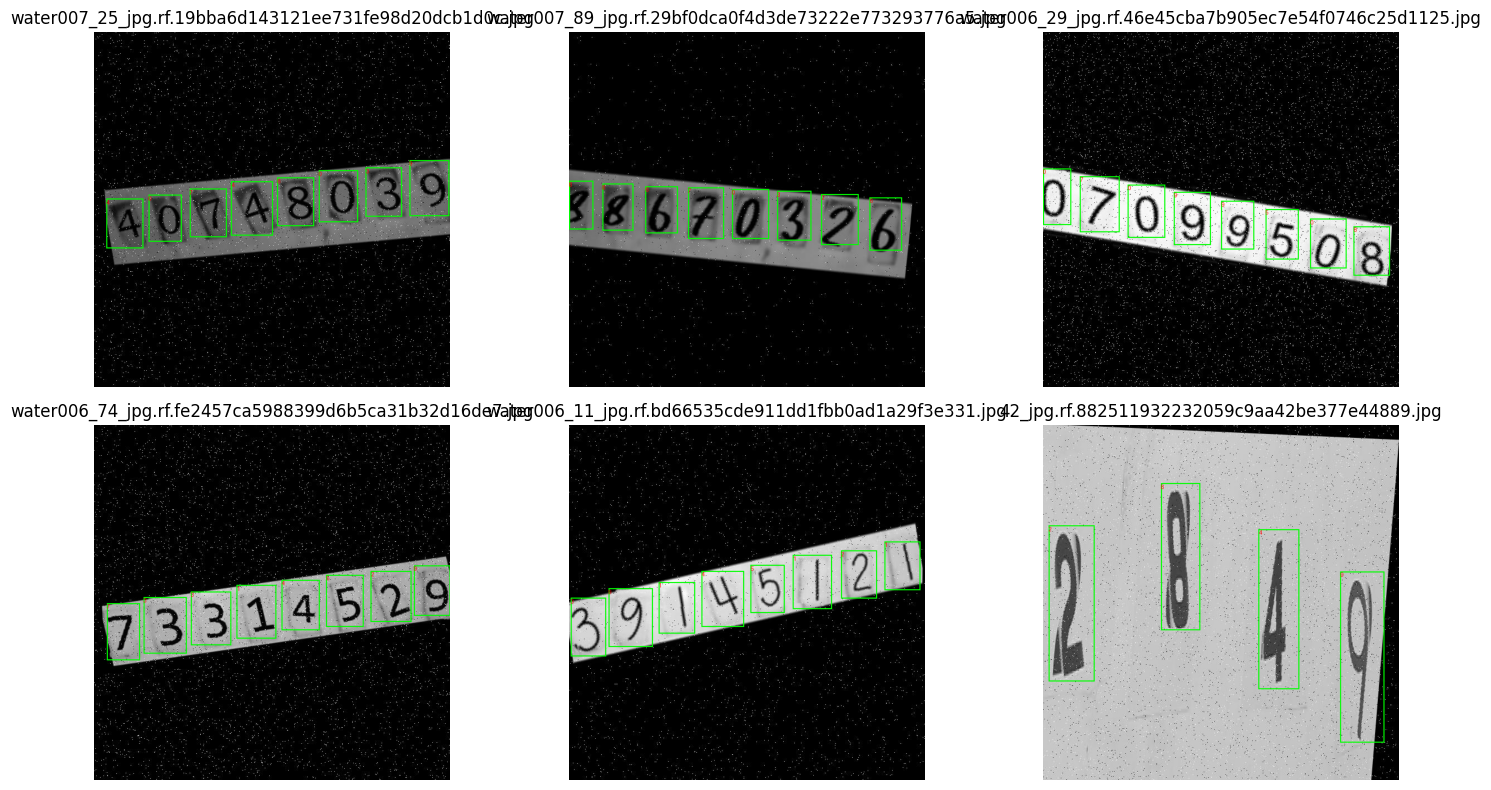

In [46]:
def yolo_to_xyxy(box, w, h):
    xc, yc, bw, bh = box
    x1 = (xc - bw / 2) * w
    y1 = (yc - bh / 2) * h
    x2 = (xc + bw / 2) * w
    y2 = (yc + bh / 2) * h
    return x1, y1, x2, y2


def show_samples(split="train", n=6):
    images = list((DATA_DIR / split / "images").glob("*"))
    if not images:
        print("No images found for", split)
        return
    sample = random.sample(images, k=min(n, len(images)))
    cols = min(3, len(sample))
    rows = math.ceil(len(sample) / cols)
    plt.figure(figsize=(5 * cols, 4 * rows))
    for i, img_path in enumerate(sample, 1):
        img = Image.open(img_path).convert("RGB")
        w, h = img.size
        lbl_path = DATA_DIR / split / "labels" / (img_path.stem + ".txt")
        draw = ImageDraw.Draw(img)
        if lbl_path.exists():
            for line in lbl_path.read_text().strip().splitlines():
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls, xc, yc, bw, bh = parts
                x1, y1, x2, y2 = yolo_to_xyxy([float(xc), float(yc), float(bw), float(bh)], w, h)
                draw.rectangle([x1, y1, x2, y2], outline=(0, 255, 0), width=2)
                draw.text((x1, y1), cls, fill=(255, 0, 0))
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_path.name)
    plt.tight_layout()
    plt.show()

show_samples("train", n=6)


In [47]:
# Training config
PRETRAIN_EPOCHS = 10
IMG_SIZE = 640
BATCH = 16
MODEL_NAME = "yolov8n.pt"


In [48]:
from ultralytics import YOLO
import torch

device = 0 if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Pretrain on NumberDetection (digits)
pretrain_model = YOLO(MODEL_NAME)
pretrain_results = pretrain_model.train(
    data=str(DATA_DIR / "data.yaml"),
    epochs=PRETRAIN_EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=device,
    name="pretrain_numberdetection",
)

BEST_PRETRAIN = Path(pretrain_results.save_dir) / "weights" / "best.pt"
print("Best pretrain weights:", BEST_PRETRAIN)


Device: cpu
Ultralytics 8.4.21 🚀 Python-3.12.6 torch-2.10.0 CPU (Apple M4 Pro)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/egorzukov/Documents/comp_vision/lab2/data/data/numberdetection/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pretrain_numberdetection3, nbs=64, nms=False, opset=None, optimize=Fa

## SVHN dataset (YOLO format)


In [49]:
SVHN_DIR = PROJECT_DIR / "data" / "svhn_yolo"
SVHN_YAML = SVHN_DIR / "data.yaml"
print("SVHN_YAML exists:", SVHN_YAML.exists())


SVHN_YAML exists: True


In [50]:
# ROBOFLOW_API_KEY = os.getenv("ROBOFLOW_API_KEY", "")
#
# if not SVHN_YAML.exists():
#     if ROBOFLOW_API_KEY:
#         ensure_pkg("roboflow")
#         from roboflow import Roboflow
#
#         rf = Roboflow(api_key=ROBOFLOW_API_KEY)
#
#         raise RuntimeError("Please edit this cell with your SVHN Roboflow project/version.")
#     else:
#         print("SVHN dataset not found. Put it under data/svhn_yolo/ with data.yaml.")


In [51]:
if not SVHN_YAML.exists():
    raise FileNotFoundError(
        f"SVHN data.yaml not found at {SVHN_YAML}. Place the dataset or download it first."
    )

FINETUNE_EPOCHS = 10

finetune_model = YOLO(str(BEST_PRETRAIN)) if BEST_PRETRAIN.exists() else YOLO(MODEL_NAME)
finetune_results = finetune_model.train(
    data=str(SVHN_YAML),
    epochs=FINETUNE_EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=device,
    name="finetune_svhn",
)

BEST_FINETUNE = Path(finetune_results.save_dir) / "weights" / "best.pt"
print("Best finetune weights:", BEST_FINETUNE)


Ultralytics 8.4.21 🚀 Python-3.12.6 torch-2.10.0 CPU (Apple M4 Pro)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/egorzukov/Documents/comp_vision/lab2/data/svhn_yolo/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/Users/egorzukov/Documents/comp_vision/lab2/runs/detect/pretrain_numberdetection3/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=finet

In [52]:
# Evaluate on SVHN test split
model = YOLO(str(BEST_FINETUNE))
metrics = model.val(data=str(SVHN_YAML), split="test", imgsz=IMG_SIZE, device=device)

# Robust extraction for different ultralytics versions
p = r = map50 = map95 = None
try:
    box = metrics.box
    p, r, map50, map95 = box.p, box.r, box.map50, box.map
except Exception:
    rd = getattr(metrics, "results_dict", {})
    p = rd.get("metrics/precision(B)")
    r = rd.get("metrics/recall(B)")
    map50 = rd.get("metrics/mAP50(B)")
    map95 = rd.get("metrics/mAP50-95(B)")

print("Precision:", p)
print("Recall:", r)
print("mAP@0.5:", map50)
print("mAP@0.5:0.95:", map95)


Ultralytics 8.4.21 🚀 Python-3.12.6 torch-2.10.0 CPU (Apple M4 Pro)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 109.0±65.1 MB/s, size: 22.3 KB)
val: Scanning /Users/egorzukov/Documents/comp_vision/lab2/data/svhn_yolo/test/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 46.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.5s/it 10.7s2.0s
                   all        100        213      0.739      0.754       0.82        0.4
                     0         13         14      0.688      0.929      0.947      0.356
                     1         38         42      0.816       0.74      0.821      0.368
                     2         33         36      0.825       0.75      0.877       0.46
                     3         24         27      0.724      0.776      0.838      0.447
                     4 

### Тестовые метрики

In [69]:
import numpy as np

def _to_float(x):
    try:
        if isinstance(x, (list, tuple, np.ndarray)):
            x = np.array(x, dtype=float)
            return float(np.mean(x))
        return float(x)
    except Exception:
        return None

try:
    box = metrics.box
    p_avg = _to_float(box.p)
    r_avg = _to_float(box.r)
    map50 = _to_float(box.map50)
    map95 = _to_float(box.map)
except Exception:
    p_avg = r_avg = map50 = map95 = None

# Fallback to results_dict
if map50 is None or map95 is None:
    rd = getattr(metrics, "results_dict", {})
    p_avg = p_avg if p_avg is not None else _to_float(rd.get("metrics/precision(B)"))
    r_avg = r_avg if r_avg is not None else _to_float(rd.get("metrics/recall(B)"))
    map50 = map50 if map50 is not None else _to_float(rd.get("metrics/mAP50(B)"))
    map95 = map95 if map95 is not None else _to_float(rd.get("metrics/mAP50-95(B)"))

print("Precision (avg):", p_avg)
print("Recall (avg):", r_avg)
print("mAP@0.5:", map50)
print("mAP@0.5:0.95:", map95)


Precision (avg): 0.739091791493178
Recall (avg): 0.7542765502920243
mAP@0.5: 0.8196316793635228
mAP@0.5:0.95: 0.4002452919492708


In [68]:
# Helpers for mean IoU
from ultralytics.utils.metrics import box_iou


def parse_yolo_labels(label_path):
    if not label_path.exists():
        return []
    boxes = []
    classes = []
    for line in label_path.read_text().strip().splitlines():
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        cls, xc, yc, bw, bh = parts
        boxes.append([float(xc), float(yc), float(bw), float(bh)])
        classes.append(int(float(cls)))
    return boxes, classes


def resolve_split_images(data_yaml, split):
    data = yaml.safe_load(Path(data_yaml).read_text())
    root = Path(data_yaml).parent
    if split in {"val", "valid"}:
        img_dir = data.get("val") or data.get("valid")
    else:
        img_dir = data.get(split)
    if img_dir is None:
        raise KeyError(f"Split '{split}' not found in {data_yaml}")
    img_dir = Path(img_dir)
    if not img_dir.is_absolute():
        img_dir = (root / img_dir).resolve()
    return img_dir


def image_to_label_path(img_path):
    p = Path(img_path)
    parts = list(p.parts)
    if "images" in parts:
        idx = parts.index("images")
        parts[idx] = "labels"
        return Path(*parts).with_suffix(".txt")
    # fallback: sibling labels dir
    return (p.parent / "labels" / p.stem).with_suffix(".txt")


def mean_iou_for_split(model, data_yaml, split="test", limit=None, conf=0.001, iou_thr=0.5):
    img_dir = resolve_split_images(data_yaml, split)
    images = sorted([p for p in img_dir.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}])
    if limit:
        images = images[:limit]

    total_iou = 0.0
    total_boxes = 0

    for img_path in images:
        # labels
        label_path = image_to_label_path(img_path)
        gt_boxes, gt_classes = parse_yolo_labels(label_path)
        if not gt_boxes:
            continue

        # predictions
        preds = model.predict(str(img_path), conf=conf, iou=iou_thr, verbose=False, device=device)[0]
        if preds.boxes is None or len(preds.boxes) == 0:
            total_boxes += len(gt_boxes)
            continue

        # prepare tensors
        w, h = Image.open(img_path).size
        gt_xyxy = []
        for (xc, yc, bw, bh) in gt_boxes:
            x1 = (xc - bw / 2) * w
            y1 = (yc - bh / 2) * h
            x2 = (xc + bw / 2) * w
            y2 = (yc + bh / 2) * h
            gt_xyxy.append([x1, y1, x2, y2])

        gt_xyxy = torch.tensor(gt_xyxy, dtype=torch.float32)
        gt_classes_t = torch.tensor(gt_classes, dtype=torch.int64)

        pred_xyxy = preds.boxes.xyxy.cpu()
        pred_classes = preds.boxes.cls.int().cpu()

        # match each GT with best prediction of the same class
        for i in range(len(gt_xyxy)):
            same_cls = pred_xyxy[pred_classes == gt_classes_t[i]]
            if same_cls.numel() == 0:
                total_boxes += 1
                continue
            ious = box_iou(gt_xyxy[i].unsqueeze(0), same_cls).squeeze(0)
            best_iou = float(ious.max().item())
            total_iou += best_iou
            total_boxes += 1

    mean_iou = total_iou / max(1, total_boxes)
    return mean_iou


In [70]:
# Sanity check: SVHN test labels
img_dir = resolve_split_images(SVHN_YAML, split="test")
# label dir heuristic
if img_dir.name == "images":
    label_dir = img_dir.parent / "labels"
else:
    label_dir = img_dir / "labels"

num_imgs = len([p for p in img_dir.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}])
num_lbls = len(list(label_dir.glob("*.txt"))) if label_dir.exists() else 0
print("Test images:", num_imgs)
print("Test labels:", num_lbls)
print("Image dir:", img_dir)
print("Label dir:", label_dir)


Test images: 100
Test labels: 100
Image dir: /Users/egorzukov/Documents/comp_vision/lab2/data/svhn_yolo/test/images
Label dir: /Users/egorzukov/Documents/comp_vision/lab2/data/svhn_yolo/test/labels


In [71]:
mean_iou = mean_iou_for_split(model, SVHN_YAML, split="test", limit=None, conf=0.001)
print("Mean IoU (matched by class):", mean_iou)


Mean IoU (matched by class): 0.6581276301731805


## Тест на своих фото

In [81]:
INF_CONF = 0.15
INF_IOU = 0.6
INF_IMGSZ = 1920
INF_MAX_DET = 500
INF_AUGMENT = True
INF_AGNOSTIC_NMS = True


Results saved to /Users/egorzukov/Documents/comp_vision/lab2/runs/detect/street_photos22


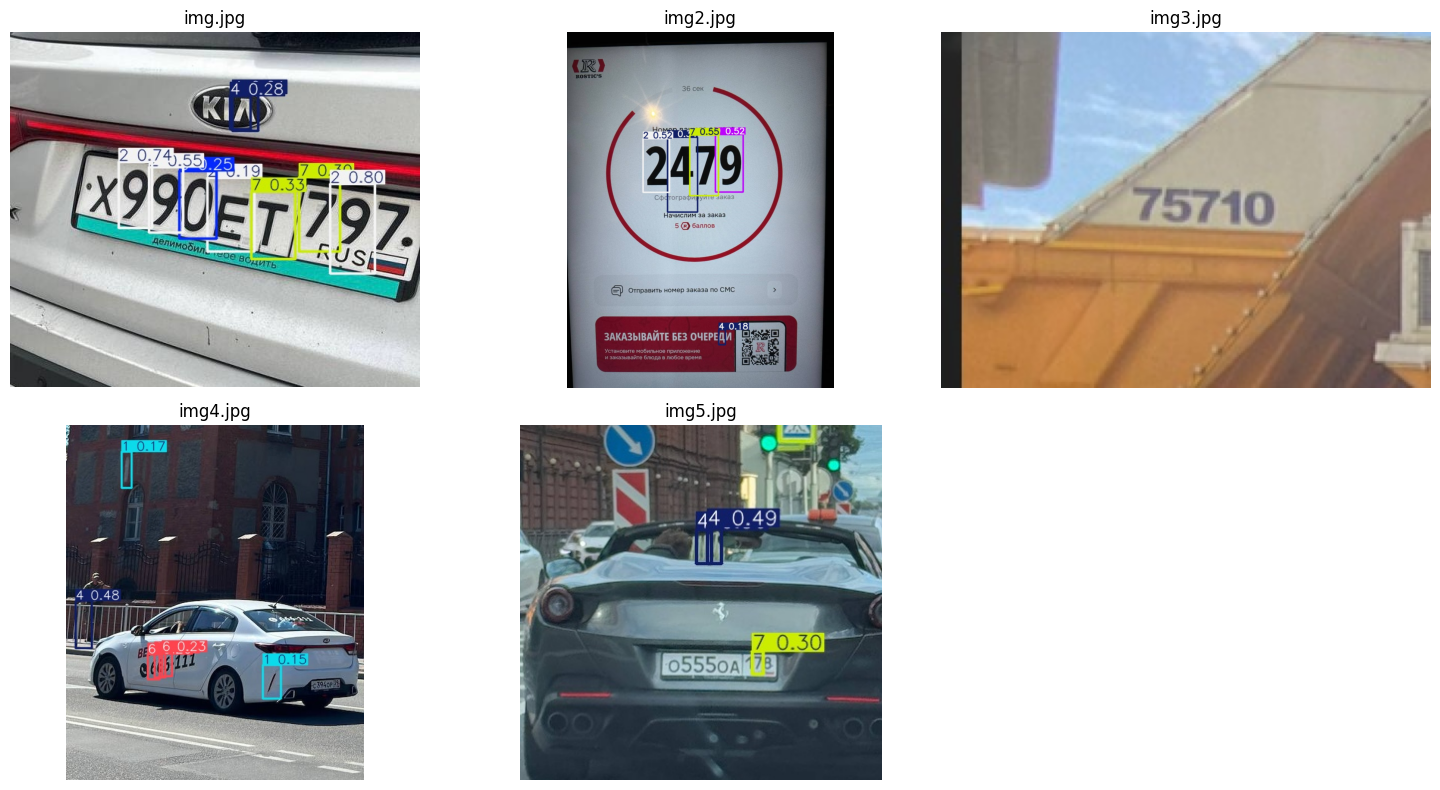

In [84]:
PREDICT_OUT = model.predict(
    source=str(PHOTOS_DIR),
    imgsz=INF_IMGSZ,
    conf=INF_CONF,
    iou=INF_IOU,
    device=device,
    save=True,
    name="street_photos",
    augment=INF_AUGMENT,
    max_det=INF_MAX_DET,
    agnostic_nms=INF_AGNOSTIC_NMS,
)

# Display a few prediction results
pred_dir = Path(PREDICT_OUT[0].save_dir)
result_images = sorted([p for p in pred_dir.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}])

if result_images:
    show_n = min(6, len(result_images))
    cols = min(3, show_n)
    rows = math.ceil(show_n / cols)
    plt.figure(figsize=(5 * cols, 4 * rows))
    for i, p in enumerate(result_images[:show_n], 1):
        img = Image.open(p).convert("RGB")
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(p.name)
    plt.tight_layout()
    plt.show()
else:
    print("No prediction images found in:", pred_dir)
